In [ ]:
# Environment setup

!nvidia-smi -L || true


!pip -q uninstall -y peft bitsandbytes albumentations albucore opencv-python opencv-python-headless || true

# Compatible versions
!pip -q install "transformers==4.41.2" "decord==0.6.0" "torchmetrics==1.4.0" "scikit-learn==1.5.1" \
                albumentations==1.4.8 albucore==0.0.14 opencv-python-headless==4.10.0.84 --no-cache-dir

import os, math, random, json, glob, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler

import decord
decord.bridge.set_bridge('native')

from transformers import (
    AutoImageProcessor,
    TimesformerForVideoClassification,
    get_linear_schedule_with_warmup,
)

from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score
from sklearn.metrics import confusion_matrix, classification_report, average_precision_score

import albumentations as A
from albumentations.core.composition import ReplayCompose

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)


GPU 0: NVIDIA L4 (UUID: GPU-55095afe-8496-2c48-9e7d-22046a214f4a)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 kB 316.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 309.8 MB/s eta 0:00:00
Device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DRIVE_DATA_ROOT = "/content/drive/MyDrive/Annotations"

# Copy to local SSD for faster I/O
COPY_TO_LOCAL = False
LOCAL_DATA_ROOT = "/content/Dataset"
if COPY_TO_LOCAL:
    os.makedirs(LOCAL_DATA_ROOT, exist_ok=True)
    !rsync -ah --info=progress2 "{DRIVE_DATA_ROOT}/" "{LOCAL_DATA_ROOT}/"
    DATA_ROOT = LOCAL_DATA_ROOT
else:
    DATA_ROOT = DRIVE_DATA_ROOT

TRAIN_DIR = os.path.join(DATA_ROOT, "train")
VAL_DIR   = os.path.join(DATA_ROOT, "val")

# Classes
CLASSES = [
    "Drinking",
    "Feeding & Lying",
    "Feeding & Standing",
    "Lying",
    "Ruminating & Lying",
    "Ruminating & Standing",
    "Standing",
]
label2id = {c:i for i,c in enumerate(CLASSES)}
id2label = {i:c for c,i in label2id.items()}

# Hyperparams
NUM_FRAMES      = 12
IMAGE_SIZE      = 224
BATCH_SIZE      = 1
ACCUM_STEPS     = 4
EPOCHS          = 3
LR              = 3e-5
WEIGHT_DECAY    = 0.01
WARMUP_RATIO    = 0.1
MAX_GRAD_NORM   = 1.0
MIXED_PRECISION = True
PATIENCE        = 4
NUM_WORKERS     = 2

# Rebalancing
BALANCING_STRATEGY = "sampler"
SAMPLER_NUM_SAMPLES = 8000

# Model
CKPT = "facebook/timesformer-base-finetuned-k400"

# Save dir
save_dir = "/content/drive/MyDrive/ablationsstudytimesformer-cows2"
os.makedirs(save_dir, exist_ok=True)

print("Classes:", label2id)
print("Data root:", DATA_ROOT)
print("Balancing:", BALANCING_STRATEGY, "| epoch draws:", SAMPLER_NUM_SAMPLES)

Classes: {'Drinking': 0, 'Feeding & Lying': 1, 'Feeding & Standing': 2, 'Lying': 3, 'Ruminating & Lying': 4, 'Ruminating & Standing': 5, 'Standing': 6}
Data root: /content/drive/MyDrive/Annotations
Balancing: sampler | epoch draws: 8000


In [ ]:
# List videos

def list_videos(root_dir, classes):
    items = []
    for cls in classes:
        cls_dir = Path(root_dir) / cls
        patterns = ["*.mp4", "*.MP4", "*.mkv", "*.MOV", "*.mov"]
        vids = []
        for p in patterns:
            vids.extend(glob.glob(str(cls_dir / p)))
        items.extend([(v, label2id[cls]) for v in vids])
    return items

train_items = list_videos(TRAIN_DIR, CLASSES)
val_items   = list_videos(VAL_DIR,   CLASSES)
print(f"Found {len(train_items)} train and {len(val_items)} val clips.")
assert len(train_items) > 0 and len(val_items) > 0


Found 3343 train and 1119 val clips.


In [ ]:
# Frame sampling and decoding

def sample_indices(num_frames_in_video, num_frames_needed, randomize: bool):
    """
    Uniformly cover the whole clip.
    - randomize=True: pick a random frame inside each segment (train)
    - randomize=False: pick the segment midpoint (val/test) for reproducibility
    """
    if num_frames_in_video <= 0:
        return np.array([0] * num_frames_needed, dtype=int)

    if num_frames_in_video <= num_frames_needed:
        return np.linspace(0, num_frames_in_video - 1, num_frames_needed).astype(int)

    ticks = np.linspace(0, num_frames_in_video - 1, num_frames_needed + 1)
    idxs = []
    for i in range(num_frames_needed):
        s = int(math.floor(ticks[i]))
        e = int(math.floor(ticks[i + 1]))
        if e <= s:
            e = s + 1

        if randomize:
            idxs.append(random.randint(s, max(s, e - 1)))
        else:
            # midpoint (deterministic)
            idxs.append((s + (e - 1)) // 2)

    return np.array(idxs, dtype=int)


def decode_video(path, num_frames, randomize: bool):
    vr = decord.VideoReader(path)
    idxs = sample_indices(len(vr), num_frames, randomize=randomize)
    batch = vr.get_batch(idxs)     # (T,H,W,C)
    frames = batch.asnumpy()       # uint8
    return [frames[i] for i in range(frames.shape[0])]


In [ ]:
# Augmentation, Dataset, Collate

image_processor = AutoImageProcessor.from_pretrained(CKPT)

# Mild, clip-consistent augmentation
'''train_augment = ReplayCompose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(0.15, 0.15, p=0.3),
    A.HueSaturationValue(5, 10, 10, p=0.2),
    A.GaussianBlur(blur_limit=(3,5), p=0.15),
    A.GaussNoise(var_limit=(5.0, 15.0), p=0.15),
], p=1.0)'''

# Augmentations done already
train_augment = None
# No augmentation
val_augment = None

class VideoDataset(Dataset):
    def __init__(self, items, num_frames: int, randomize: bool, augmenter=None):
        self.items = items
        self.num_frames = num_frames
        self.randomize = randomize
        self.augmenter = augmenter

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, label = self.items[idx]
        frames = decode_video(path, self.num_frames, randomize=self.randomize)  # <-- changed

        if self.augmenter is not None:
            first = self.augmenter(image=frames[0])
            replay = first["replay"]
            frames = [ReplayCompose.replay(replay, image=f)["image"] for f in frames]

        return {"video": frames, "label": label, "path": path}


def collate_fn(batch):
    videos = [b["video"] for b in batch]
    labels = torch.tensor([b["label"] for b in batch], dtype=torch.long)
    proc = image_processor(videos, return_tensors="pt")  # (B,3,T,H,W)
    return {"pixel_values": proc["pixel_values"], "labels": labels}

#train_ds = VideoDataset(train_items, augmenter=train_augment)
#val_ds   = VideoDataset(val_items,   augmenter=val_augment)

In [ ]:
# WeightedRandomSampler

from torch.utils.data import WeightedRandomSampler

# Per class counts from train set
counts = np.zeros(len(CLASSES), dtype=np.int64)
for _, y in train_items: counts[y] += 1
print("Original train counts:", dict(zip(CLASSES, counts)))

# Random oversampling proportional to inverse counts
w_per_class = np.zeros_like(counts, dtype=float)
nz = counts > 0
w_per_class[nz] = 1.0 / counts[nz]

# Normalize for nicer scales
w_per_class = w_per_class / (w_per_class.mean() if w_per_class.mean() > 0 else 1.0)

sample_weights = [w_per_class[y] for _, y in train_items]
num_samples = int(SAMPLER_NUM_SAMPLES) if SAMPLER_NUM_SAMPLES else len(train_items)

sampler = WeightedRandomSampler(
    torch.DoubleTensor(sample_weights),
    num_samples=num_samples,
    replacement=True
)

def make_loaders_for_num_frames(num_frames: int):
    train_ds = VideoDataset(
        train_items,
        num_frames=num_frames,
        randomize=True,
        augmenter=train_augment
    )

    val_ds = VideoDataset(
        val_items,
        num_frames=num_frames,
        randomize=False,
        augmenter=val_augment
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        sampler=sampler,   # keep your existing sampler
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=(NUM_WORKERS > 0),
        prefetch_factor=(2 if NUM_WORKERS > 0 else None),
        collate_fn=collate_fn,
        drop_last=True
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=(NUM_WORKERS > 0),
        prefetch_factor=(2 if NUM_WORKERS > 0 else None),
        collate_fn=collate_fn
    )

    return train_loader, val_loader



# Per epoch counts
def summarize_effective_counts_sampler(sampler, train_items):
    idxs = list(iter(sampler))  # indices drawn for one epoch; no decoding
    eff = np.zeros(len(CLASSES), dtype=int)
    for i in idxs:
        _, y = train_items[int(i)]
        eff[y] += 1
    return eff, len(idxs)

eff_counts, total = summarize_effective_counts_sampler(sampler, train_items)
df_counts = pd.DataFrame({
    "class": CLASSES,
    "original_count": counts,
    "effective_count_per_epoch": eff_counts
})
df_counts["oversample_gain"] = df_counts["effective_count_per_epoch"] - df_counts["original_count"]
df_counts.loc["TOTAL"] = ["—", counts.sum(), eff_counts.sum(), eff_counts.sum()-counts.sum()]
print(f"Epoch draws (target): {num_samples}")
display(df_counts)


Original train counts: {'Drinking': np.int64(35), 'Feeding & Lying': np.int64(20), 'Feeding & Standing': np.int64(125), 'Lying': np.int64(149), 'Ruminating & Lying': np.int64(82), 'Ruminating & Standing': np.int64(45), 'Standing': np.int64(44)}
Epoch draws (target): 8000


,class,original_count,effective_count_per_epoch,oversample_gain
0,Drinking,35,1171,1136
1,Feeding & Lying,20,1152,1132
2,Feeding & Standing,125,1154,1029
3,Lying,149,1114,965
4,Ruminating & Lying,82,1161,1079
5,Ruminating & Standing,45,1111,1066
6,Standing,44,1137,1093
TOTAL,—,500,8000,7500


In [ ]:
# Model & Loss

model = TimesformerForVideoClassification.from_pretrained(
    CKPT,
    num_labels=len(CLASSES),
    ignore_mismatched_sizes=True,
    label2id=label2id,
    id2label=id2label,
)
model.config.num_frames = NUM_FRAMES
model.config.image_size = IMAGE_SIZE
model.to(device)

# Use plain CE
criterion = nn.CrossEntropyLoss()


In [ ]:
from sklearn.metrics import accuracy_score, f1_score
import torch
import numpy as np

@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()

    all_preds = []
    all_labels = []
    running_loss = 0.0
    n_seen = 0

    for batch in val_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        logits = model(pixel_values=pixel_values).logits
        loss = criterion(logits, labels)

        preds = torch.argmax(logits, dim=1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

        running_loss += loss.item() * labels.size(0)
        n_seen += labels.size(0)

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    val_loss = running_loss / max(1, n_seen)
    val_acc = accuracy_score(all_labels, all_preds)
    val_f1 = f1_score(all_labels, all_preds, average="macro")

    return val_loss, val_acc, val_f1


In [ ]:
# ==========================================================
# Temporal Sampling Ablation: 12 vs 16 vs 32 frames / 10s clip
# ==========================================================

import copy, time, math
import pandas as pd
import torch
from transformers import AdamW, get_linear_schedule_with_warmup
from torch.cuda.amp import autocast, GradScaler

def build_fresh_model():
    return TimesformerForVideoClassification.from_pretrained(
        CKPT,
        num_labels=len(CLASSES),
        ignore_mismatched_sizes=True,
        label2id=label2id,
        id2label=id2label,
    ).to(device)

def run_one_ablation(num_frames):
    print(f"\n===== Running ablation for {num_frames} frames (~{num_frames/10:.2f} fps) =====")

    train_loader, val_loader = make_loaders_for_num_frames(num_frames)

    model = build_fresh_model()

    model.gradient_checkpointing_enable()
    model.config.output_attentions = False
    model.config.output_hidden_states = False
    num_training_steps = EPOCHS * math.ceil(len(train_loader) / ACCUM_STEPS)
    num_warmup_steps = int(WARMUP_RATIO * num_training_steps)

    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps, num_training_steps
    )
    scaler = GradScaler(enabled=(device.type == "cuda" and MIXED_PRECISION))

    best_state = None
    best_f1 = -1.0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        optimizer.zero_grad(set_to_none=True)

        running_loss, n_seen = 0.0, 0
        t0 = time.time()

        for step, batch in enumerate(train_loader, start=1):
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            with autocast(enabled=(device.type == "cuda" and MIXED_PRECISION)):
                logits = model(pixel_values=pixel_values).logits
                loss = criterion(logits, labels) / ACCUM_STEPS

            scaler.scale(loss).backward()

            if step % ACCUM_STEPS == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
                scheduler.step()

            running_loss += loss.item() * labels.size(0) * ACCUM_STEPS
            n_seen += labels.size(0)

        train_loss = running_loss / max(1, n_seen)
        val_loss, val_acc, val_f1 = evaluate(model, val_loader)

        print(
            f"[{num_frames:02d}f] Epoch {epoch}/{EPOCHS} | "
            f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
            f"val_acc={val_acc:.4f} | val_macroF1={val_f1:.4f} | "
            f"time={time.time()-t0:.1f}s"
        )

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = copy.deepcopy(model.state_dict())

    if best_state is not None:
        model.load_state_dict(best_state)

    val_loss, val_acc, val_f1 = evaluate(model, val_loader)

    return {
        "num_frames": num_frames,
        "effective_fps": num_frames / 10.0,
        "val_acc": val_acc,
        "val_macroF1": val_f1,
    }

# ---- Run all ablations ----
results = []
for nf in (32, ): #(12, 16, 32):
    results.append(run_one_ablation(nf))

df_ablation = pd.DataFrame(results)
display(df_ablation)



===== Running ablation for 32 frames (~3.20 fps) =====


Some weights of TimesformerForVideoClassification were not initialized from the model checkpoint at facebook/timesformer-base-finetuned-k400 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([400, 768]) in the checkpoint and torch.Size([7, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([400]) in the checkpoint and torch.Size([7]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1367876840.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(device.type == "cuda" and MIXED_PRECISION))
/usr/local/lib/python3.12/dist-packages/transformers/feature_extraction_utils.py:141: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a sing

[32f] Epoch 1/3 | train_loss=0.2354 | val_loss=1.5482 | val_acc=0.7200 | val_macroF1=0.6460 | time=4461.7s


/tmp/ipython-input-1367876840.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda" and MIXED_PRECISION)):


[32f] Epoch 2/3 | train_loss=0.0001 | val_loss=1.8036 | val_acc=0.7000 | val_macroF1=0.6178 | time=4456.1s


/tmp/ipython-input-1367876840.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda" and MIXED_PRECISION)):


[32f] Epoch 3/3 | train_loss=0.0000 | val_loss=1.8657 | val_acc=0.7000 | val_macroF1=0.6178 | time=4465.1s


,num_frames,effective_fps,val_acc,val_macroF1
0,32,3.2,0.72,0.646009


In [ ]:
csv_path = os.path.join(save_dir, "timesformer_sampling_ablation.csv")
df_ablation.to_csv(csv_path, index=False)
print(f"Saved CSV to: {csv_path}")

In [ ]:
# Train / Validate (early stopping + save best)

history = {"epoch": [], "train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}
best_val_loss = float('inf')
best_val_acc  = 0.0
stale = 0
global_step = 0

def evaluate(model, loader):
    model.eval()
    acc_metric = MulticlassAccuracy(num_classes=len(CLASSES)).to(device)
    f1_metric  = MulticlassF1Score(num_classes=len(CLASSES), average="macro").to(device)
    total_loss, n = 0.0, 0
    with torch.no_grad():
        for batch in loader:
            pixel_values = batch["pixel_values"].to(device, non_blocking=True)
            labels       = batch["labels"].to(device, non_blocking=True)
            logits = model(pixel_values=pixel_values).logits
            loss = criterion(logits, labels)
            total_loss += loss.item() * labels.size(0)
            n += labels.size(0)
            acc_metric.update(logits, labels)
            f1_metric.update(logits, labels)
    return total_loss / max(1,n), acc_metric.compute().item(), f1_metric.compute().item()

for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss, num_train_examples = 0.0, 0
    optimizer.zero_grad(set_to_none=True)
    t0 = time.time()

    for step, batch in enumerate(train_loader, start=1):
        pixel_values = batch["pixel_values"].to(device, non_blocking=True)
        labels       = batch["labels"].to(device, non_blocking=True)

        with autocast(enabled=(device.type == "cuda" and MIXED_PRECISION)):
            logits = model(pixel_values=pixel_values).logits
            loss = criterion(logits, labels) / ACCUM_STEPS

        scaler.scale(loss).backward()
        if step % ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer); scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()
            global_step += 1

        running_loss += loss.item() * labels.size(0)
        num_train_examples += labels.size(0)

    val_loss, val_acc, val_f1 = evaluate(model, val_loader)
    train_loss = running_loss / max(1, num_train_examples)
    dt = time.time() - t0
    print(f"Epoch {epoch:02d}/{EPOCHS}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
          f"val_acc={val_acc:.4f}  val_f1={val_f1:.4f}  ({dt/60:.1f} min)")

    # Log + persist history
    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)
    pd.DataFrame(history).to_csv(os.path.join(save_dir, "training_history.csv"), index=False)

    # Save best by val_acc
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        model.save_pretrained(save_dir)
        image_processor.save_pretrained(save_dir)
        with open(os.path.join(save_dir, "labels.json"), "w") as f:
            json.dump({"label2id": label2id, "id2label": id2label}, f, indent=2)
        print(f"✅ Saved new best to {save_dir} (val_acc={val_acc:.4f})")

    # Early stopping by val_loss
    if val_loss + 1e-6 < best_val_loss:
        best_val_loss = val_loss
        stale = 0
    else:
        stale += 1
        if stale >= PATIENCE:
            print("⏹️ Early stopping triggered.")
            break

    # Always keep a last checkpoint
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "label2id": label2id,
        "id2label": id2label,
        "num_frames": NUM_FRAMES,
    }, os.path.join(save_dir, "last.pt"))

print("Training complete.")


Epoch 01/20  train_loss=0.0239  val_loss=0.6556  val_acc=0.8203  val_f1=0.8242  (36.9 min)
✅ Saved new best to /content/drive/MyDrive/Models/timesformer-cows2 (val_acc=0.8203)
Epoch 02/20  train_loss=0.0143  val_loss=0.8325  val_acc=0.8065  val_f1=0.8204  (34.6 min)
Epoch 03/20  train_loss=0.0092  val_loss=0.9430  val_acc=0.8266  val_f1=0.8178  (34.2 min)
✅ Saved new best to /content/drive/MyDrive/Models/timesformer-cows2 (val_acc=0.8266)
Epoch 04/20  train_loss=0.0066  val_loss=0.7795  val_acc=0.8433  val_f1=0.8432  (34.3 min)
✅ Saved new best to /content/drive/MyDrive/Models/timesformer-cows2 (val_acc=0.8433)
Epoch 05/20  train_loss=0.0071  val_loss=0.8581  val_acc=0.8276  val_f1=0.8236  (34.3 min)
⏹️ Early stopping triggered.
Training complete.


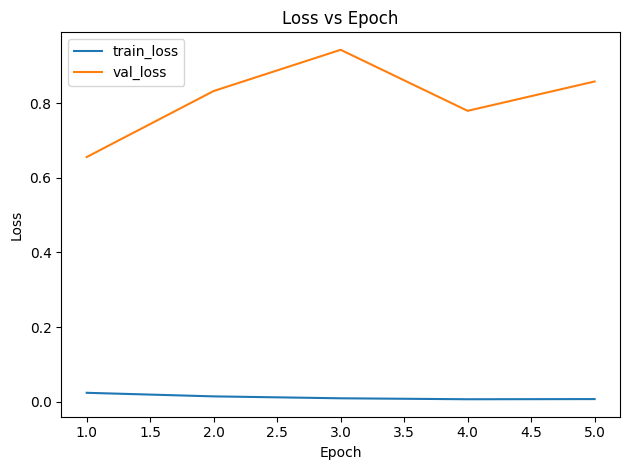

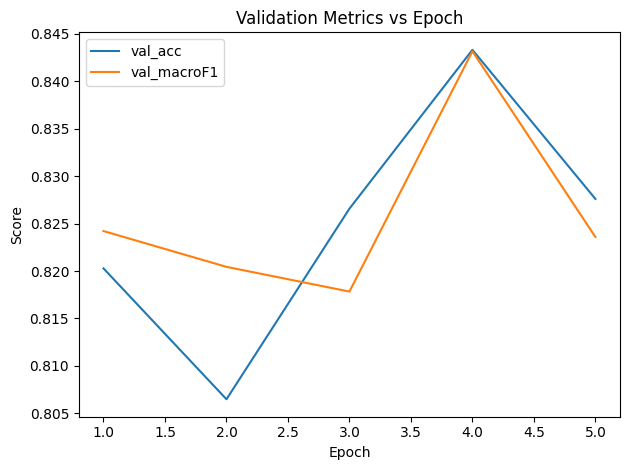

In [ ]:
# Curves: Loss / Macro-F1

hist_df = pd.DataFrame(history)

plt.figure()
plt.plot(hist_df["epoch"], hist_df["train_loss"], label="train_loss")
plt.plot(hist_df["epoch"], hist_df["val_loss"], label="val_loss")
plt.title("Loss vs Epoch"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.tight_layout(); plt.savefig(os.path.join(save_dir, "loss_curve.png"), dpi=150); plt.show()

plt.figure()
plt.plot(hist_df["epoch"], hist_df["val_acc"], label="val_acc")
plt.plot(hist_df["epoch"], hist_df["val_f1"], label="val_macroF1")
plt.title("Validation Metrics vs Epoch"); plt.xlabel("Epoch"); plt.ylabel("Score"); plt.legend()
plt.tight_layout(); plt.savefig(os.path.join(save_dir, "metrics_curve.png"), dpi=150); plt.show()


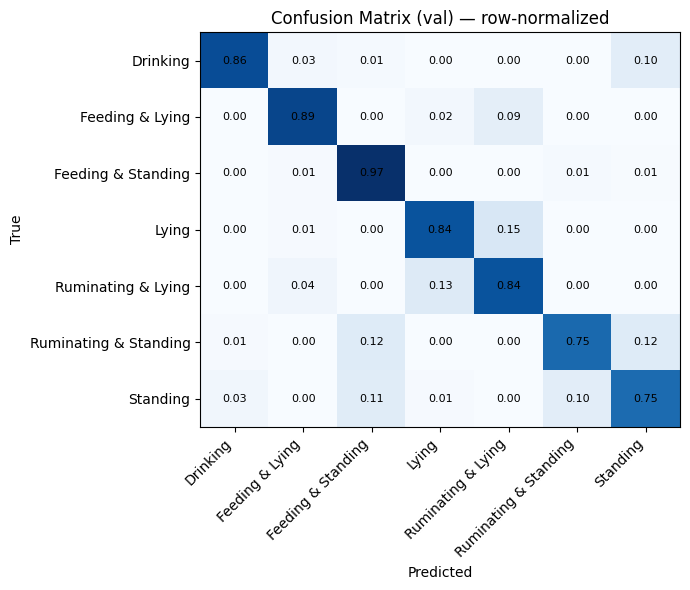

,precision,recall,f1-score,support
Drinking,0.944444,0.860759,0.900662,79.000000
Feeding & Lying,0.722222,0.886364,0.795918,44.000000
Feeding & Standing,0.915541,0.967857,0.940972,280.000000
Lying,0.917763,0.837838,0.875981,333.000000
Ruminating & Lying,0.739130,0.836066,0.784615,183.000000
Ruminating & Standing,0.844444,0.752475,0.795812,101.000000
Standing,0.770833,0.747475,0.758974,99.000000
accuracy,0.857909,0.857909,0.857909,0.857909
macro avg,0.836340,0.841262,0.836134,1119.000000
weighted avg,0.862572,0.857909,0.858308,1119.000000


              Drinking: recall=0.861
       Feeding & Lying: recall=0.886
    Feeding & Standing: recall=0.968
                 Lying: recall=0.838
    Ruminating & Lying: recall=0.836
 Ruminating & Standing: recall=0.752
              Standing: recall=0.747


In [ ]:
# Confusion matrix + per-class report

@torch.no_grad()
def collect_predictions(loader):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    for batch in loader:
        pixel_values = batch["pixel_values"].to(device, non_blocking=True)
        labels       = batch["labels"].to(device, non_blocking=True)
        logits = model(pixel_values=pixel_values).logits
        probs  = torch.softmax(logits, dim=-1)
        preds  = torch.argmax(probs, dim=-1)
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    return (np.concatenate(all_probs, axis=0),
            np.concatenate(all_preds, axis=0),
            np.concatenate(all_labels, axis=0))

y_scores, y_pred, y_true = collect_predictions(val_loader)

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CLASSES))))
cm_norm = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

plt.figure(figsize=(7,6))
plt.imshow(cm_norm, aspect="auto", cmap=plt.cm.Blues)
plt.title("Confusion Matrix (val) — row-normalized")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.xticks(ticks=np.arange(len(CLASSES)), labels=CLASSES, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(CLASSES)), labels=CLASSES)
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(save_dir, "confusion_matrix.png"), dpi=150); plt.show()

report = classification_report(y_true, y_pred, target_names=CLASSES, digits=3, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv(os.path.join(save_dir, "classification_report.csv"))
display(report_df)

per_class_recall = (cm.diagonal() / np.clip(cm.sum(axis=1), 1, None))
for cls, rec in zip(CLASSES, per_class_recall):
    print(f"{cls:>22s}: recall={rec:.3f}")


In [ ]:
# mAP

num_classes = len(CLASSES)
y_true_bin = np.eye(num_classes)[y_true]  # (N, C)

aps = []
for c in range(num_classes):
    ap_c = average_precision_score(y_true_bin[:, c], y_scores[:, c])
    aps.append(ap_c)
    print(f"AP[{CLASSES[c]}] = {100*ap_c:.2f}%")
mAP_macro = float(np.mean(aps))
print(f"\n==> mAP (macro) on val: {100*mAP_macro:.2f}%")

pd.DataFrame({"class": CLASSES, "AP": aps, "AP_%": [100*a for a in aps]}).to_csv(
    os.path.join(save_dir, "per_class_AP.csv"), index=False
)


AP[Drinking] = 95.38%
AP[Feeding & Lying] = 84.46%
AP[Feeding & Standing] = 97.36%
AP[Lying] = 94.71%
AP[Ruminating & Lying] = 84.62%
AP[Ruminating & Standing] = 83.14%
AP[Standing] = 83.42%

==> mAP (macro) on val: 89.01%
